In [16]:
pip install hf_xet

   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
   ---------- ----------------------------- 0.8/2.9 MB 4.5 MB/s eta 0:00:01
   ---------------------------- ----------- 2.1/2.9 MB 5.5 MB/s eta 0:00:01
   ---------------------------------------- 2.9/2.9 MB 5.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import itertools
import time
from tqdm.notebook import tqdm
import hf_xet
# PyTorch imports
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score

from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, get_linear_schedule_with_warmup

# configs
DATASET_PATH = 'merged_dataset(1).csv'
MODEL_SAVE_PATH = 'best_distilbert_pytorch_model.bin'
PRE_TRAINED_MODEL_NAME = 'distilbert-base-uncased'

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


Loading dataset from 'merged_dataset(1).csv' to analyze text lengths...
Calculating the length of each text...

Statistical Analysis of Text Lengths
Your chosen MAX_LEN: 256
Percentage of texts with length <= 256: 63.85%
------------------------------
80th percentile: 362 words (i.e., 80% of texts are this length or shorter)
90th percentile: 466 words (i.e., 90% of texts are this length or shorter)
95th percentile: 582 words (i.e., 95% of texts are this length or shorter)
98th percentile: 742 words (i.e., 98% of texts are this length or shorter)
99th percentile: 867 words (i.e., 99% of texts are this length or shorter)
100th percentile: 7904 words (i.e., 100% of texts are this length or shorter)

Generating Visualization...


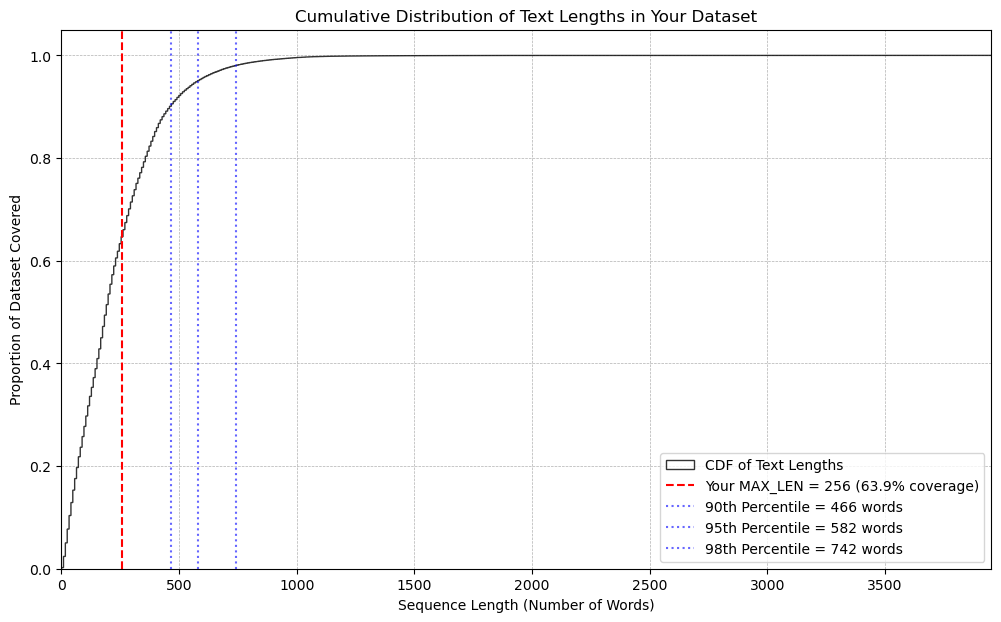

In [2]:
#EDA to choose a proper maximum length of a token (256 or 512)
MAX_LEN_TO_CHECK = 256

print(f"Loading dataset from '{DATASET_PATH}' to analyze text lengths...")

df = pd.read_csv(DATASET_PATH)

# data cleaning
# no empty texts and that the columns are strings
df.dropna(subset=['text'], inplace=True)
df['text'] = df['text'].astype(str)

print("Calculating the length of each text...")
# split by whitespace for token count (its fast)
sequence_lengths = [len(text.split()) for text in df['text'].values]

print("\n" + "="*60)
print("Statistical Analysis of Text Lengths")
print("="*60)

# percentage of texts covered by MAX_LEN
num_texts = len(sequence_lengths)
texts_within_limit = sum(1 for length in sequence_lengths if length <= MAX_LEN_TO_CHECK)
coverage_percentage = (texts_within_limit / num_texts) * 100

print(f"Your chosen MAX_LEN: {MAX_LEN_TO_CHECK}")
print(f"Percentage of texts with length <= {MAX_LEN_TO_CHECK}: {coverage_percentage:.2f}%")
print("-" * 30)

# key percentiles to find optimal lengths
percentiles = [80, 90, 95, 98, 99, 100]
for p in percentiles:
    length_at_percentile = int(np.percentile(sequence_lengths, p))
    print(f"{p}th percentile: {length_at_percentile} words (i.e., {p}% of texts are this length or shorter)")

# Cumulative distribution function (CDF)
print("\n" + "="*60)
print("Generating Visualization...")
print("="*60)

plt.figure(figsize=(12, 7))

plt.hist(sequence_lengths, bins=1000, density=True, cumulative=True,
         label='CDF of Text Lengths', histtype='step', alpha=0.8, color='k')

# vertical line for MAX_LEN
plt.axvline(x=MAX_LEN_TO_CHECK, color='red', linestyle='--',
            label=f'Your MAX_LEN = {MAX_LEN_TO_CHECK} ({coverage_percentage:.1f}% coverage)')

# lines for key percentiles
for p in [90, 95, 98]:
    length_at_p = int(np.percentile(sequence_lengths, p))
    plt.axvline(x=length_at_p, color='blue', linestyle=':',
                label=f'{p}th Percentile = {length_at_p} words', alpha=0.6)


plt.title('Cumulative Distribution of Text Lengths in Your Dataset')
plt.xlabel('Sequence Length (Number of Words)')
plt.ylabel('Proportion of Dataset Covered')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.xlim(0, max(sequence_lengths) / 2) # Zoom in on the most relevant part of the distribution
plt.show()

In [3]:
print("\n" + "="*60)
print("Step 1: Loading and splitting data with leakage prevention...")
print("="*60)
df = pd.read_csv(DATASET_PATH)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df.dropna(subset=['text'], inplace=True)
df['text'] = df['text'].astype(str)
train_sources = ['HC3_reddit_eli5', 'HC3_finance', 'DAIGT_v2_Distance learning', 'DAIGT_v2_Seeking multiple opinions', 'HC3_open_qa']
val_sources = ['DAIGT_v2_Car-free cities', 'DAIGT_v2_Does the electoral college work?', 'DAIGT_v2_Facial action coding system', 'DAIGT_v2_Mandatory extracurricular activities', 'DAIGT_v2_Summer projects', 'HC3_medicine', 'DAIGT_v2_Driverless cars', 'DAIGT_v2_Exploring Venus']
test_sources = ['DAIGT_v2_Cell phones at school', 'DAIGT_v2_Grades for extracurricular activities', 'DAIGT_v2_Community service', 'DAIGT_v2_"A Cowboy Who Rode the Waves"', 'DAIGT_v2_The Face on Mars', 'HC3_wiki_csai', 'DAIGT_v2_Phones and driving']
train_df = df[df['source'].isin(train_sources)]
val_df = df[df['source'].isin(val_sources)]
test_df = df[df['source'].isin(test_sources)]
X_train, y_train = train_df['text'].values, train_df['label'].values
X_val, y_val = val_df['text'].values, val_df['label'].values
X_test, y_test = test_df['text'].values, test_df['label'].values
print(f"Training set size:   {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size:       {len(X_test)}")


Step 1: Loading and splitting data with leakage prevention...
Training set size:   85897
Validation set size: 24987
Test set size:       13311


In [4]:
print("\n" + "="*60)
print("Step 2: Creating PyTorch Datasets and DataLoaders...")
print("="*60)

tokenizer = DistilBertTokenizer.from_pretrained(PRE_TRAINED_MODEL_NAME)
MAX_LEN = 512
print(f"Sequence length (MAX_LEN) set to: {MAX_LEN}")

class AITextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts, self.labels, self.tokenizer, self.max_len = texts, labels, tokenizer, max_len
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, item):
        text, label = str(self.texts[item]), self.labels[item]
        encoding = self.tokenizer.encode_plus(
            text, add_special_tokens=True, max_length=self.max_len,
            return_token_type_ids=False, padding='max_length',
            truncation=True, return_attention_mask=True, return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

def create_data_loader(texts, labels, tokenizer, max_len, batch_size, shuffle=False):
    ds = AITextDataset(texts=texts, labels=labels, tokenizer=tokenizer, max_len=max_len)
    return DataLoader(ds, batch_size=batch_size, num_workers=0, shuffle=shuffle)

print("Tokenizer and Dataset class are ready.")


Step 2: Creating PyTorch Datasets and DataLoaders...
Sequence length (MAX_LEN) set to: 512
Tokenizer and Dataset class are ready.


In [5]:
# training and evaluation functions
print("\n" + "="*60)
print("Step 3: Defining manual training and evaluation loops...")
print("="*60)

def train_epoch(model, data_loader, optimizer, device, scheduler):
    model = model.train()
    total_loss = 0
    for batch in tqdm(data_loader, desc="Training", leave=False):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
    return total_loss / len(data_loader)

def eval_model(model, data_loader, device):
    model = model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluating", leave=False):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            total_loss += loss.item()
            logits = outputs.logits
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
    avg_loss = total_loss / len(data_loader)
    accuracy = accuracy_score(all_labels, all_preds)
    return avg_loss, accuracy

print("Training and evaluation functions are ready.")


Step 3: Defining manual training and evaluation loops...
Training and evaluation functions are ready.


In [6]:
print("\n" + "="*60)
print("Step 4: Performing Manual Hyperparameter Search...")
print("="*60)

param_grid = {
    'learning_rate': [3e-5, 2e-5],
    'batch_size': [8, 16], # to account for increased max_len
    'epochs': [3]
}
print(f"New parameter grid for search: {param_grid}")

all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
best_val_accuracy, best_params, results_log = 0, {}, []
total_grid_search_start_time = time.time()

for i, params in enumerate(all_params):
    print(f"\n--- Testing Config {i+1}/{len(all_params)}: {params} ---")
    
    model = DistilBertForSequenceClassification.from_pretrained(PRE_TRAINED_MODEL_NAME, num_labels=2).to(device)
    optimizer = AdamW(model.parameters(), lr=params['learning_rate'])
    
    train_loader = create_data_loader(X_train, y_train, tokenizer, MAX_LEN, params['batch_size'], shuffle=True)
    val_loader = create_data_loader(X_val, y_val, tokenizer, MAX_LEN, params['batch_size'])
    
    total_steps = len(train_loader) * params['epochs']
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)
    
    config_train_start_time = time.time()
    for epoch in range(params['epochs']):
        print(f"  Epoch {epoch + 1}/{params['epochs']}")
        train_loss = train_epoch(model, train_loader, optimizer, device, scheduler)
        val_loss, val_accuracy = eval_model(model, val_loader, device)
        print(f"  Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_accuracy:.4f}")
        
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_params = params
            torch.save(model.state_dict(), MODEL_SAVE_PATH)
            print(f"  -> New best validation accuracy! Model saved.")
    
    config_train_end_time = time.time()
    training_time = config_train_end_time - config_train_start_time

    # inference time for this config
    inference_start_time = time.time()
    _, _ = eval_model(model, val_loader, device) # We just need to run it, ignore output
    inference_end_time = time.time()
    inference_time = inference_end_time - inference_start_time
    
    results_log.append({
        'config': str(params), 'val_accuracy': val_accuracy, 
        'training_time_s': training_time, 'inference_time_s': inference_time
    })

total_grid_search_end_time = time.time()
print("\n" + "="*60)
print(f"Grid Search Complete in {total_grid_search_end_time - total_grid_search_start_time:.2f} seconds!")
print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")
print(f"Best Hyperparameters: {best_params}")
print(f"Best model state saved to '{MODEL_SAVE_PATH}'")

print("\n--- Detailed Grid Search Results ---")
results_df = pd.DataFrame(results_log)
print(results_df.sort_values(by='val_accuracy', ascending=False))



Step 4: Performing Manual Hyperparameter Search...
New parameter grid for search: {'learning_rate': [3e-05, 2e-05], 'batch_size': [8, 16], 'epochs': [3]}

--- Testing Config 1/4: {'learning_rate': 3e-05, 'batch_size': 8, 'epochs': 3} ---


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Epoch 1/3


Training:   0%|          | 0/10738 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/3124 [00:00<?, ?it/s]

...

Training:   0%|          | 0/5369 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/1562 [00:00<?, ?it/s]

  Train Loss: 0.0018 | Val Loss: 0.4147 | Val Acc: 0.9469


Evaluating:   0%|          | 0/1562 [00:00<?, ?it/s]


Grid Search Complete in 9554.14 seconds!
Best Validation Accuracy: 0.9541
Best Hyperparameters: {'learning_rate': 3e-05, 'batch_size': 8, 'epochs': 3}
Best model state saved to 'best_distilbert_pytorch_model.bin'

--- Detailed Grid Search Results ---
                                              config  val_accuracy  \
2  {'learning_rate': 2e-05, 'batch_size': 8, 'epo...      0.949054   
3  {'learning_rate': 2e-05, 'batch_size': 16, 'ep...      0.946932   
1  {'learning_rate': 3e-05, 'batch_size': 16, 'ep...      0.943771   
0  {'learning_rate': 3e-05, 'batch_size': 8, 'epo...      0.942690   

   training_time_s  inference_time_s  
2      2355.476111        142.514878  
3      2144.663774        134.314473  
1      2145.686293        135.173788  
0      2353.377341        138.887783  


In [7]:
print("\n" + "="*60)
print("Step 5: Performing final training run with best parameters to get epoch history...")
print("="*60)

final_model = DistilBertForSequenceClassification.from_pretrained(PRE_TRAINED_MODEL_NAME, num_labels=2).to(device)
final_optimizer = AdamW(final_model.parameters(), lr=best_params['learning_rate'])
final_train_loader = create_data_loader(X_train, y_train, tokenizer, MAX_LEN, best_params['batch_size'], shuffle=True)
final_val_loader = create_data_loader(X_val, y_val, tokenizer, MAX_LEN, best_params['batch_size'])
final_total_steps = len(final_train_loader) * best_params['epochs']
final_scheduler = get_linear_schedule_with_warmup(final_optimizer, num_warmup_steps=0, num_training_steps=final_total_steps)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_final_val_acc = 0

for epoch in range(best_params['epochs']):
    print(f"--- Final Training Epoch {epoch + 1}/{best_params['epochs']} ---")
    train_loss = train_epoch(final_model, final_train_loader, final_optimizer, device, final_scheduler)
    # separate accuracy calculation for training set
    _, train_accuracy = eval_model(final_model, final_train_loader, device)
    val_loss, val_accuracy = eval_model(final_model, final_val_loader, device)
    
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.4f}")
    print(f"  Val Loss: {val_loss:.4f}   | Val Acc: {val_accuracy:.4f}")
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_accuracy)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_accuracy)

    if val_accuracy > best_final_val_acc:
        best_final_val_acc = val_accuracy
        torch.save(final_model.state_dict(), MODEL_SAVE_PATH)
        print("  -> Best model weights for final run saved.")


Step 5: Performing final training run with best parameters to get epoch history...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


--- Final Training Epoch 1/3 ---


Training:   0%|          | 0/10738 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/10738 [00:00<?, ?it/s]

...

  Train Loss: 0.0104 | Train Acc: 0.9995
  Val Loss: 0.4306   | Val Acc: 0.9533
  -> Best model weights for final run saved.
--- Final Training Epoch 3/3 ---


Training:   0%|          | 0/10738 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/10738 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/3124 [00:00<?, ?it/s]

  Train Loss: 0.0022 | Train Acc: 0.9998
  Val Loss: 0.5136   | Val Acc: 0.9521



Step 6: Evaluating the final model on the test set...


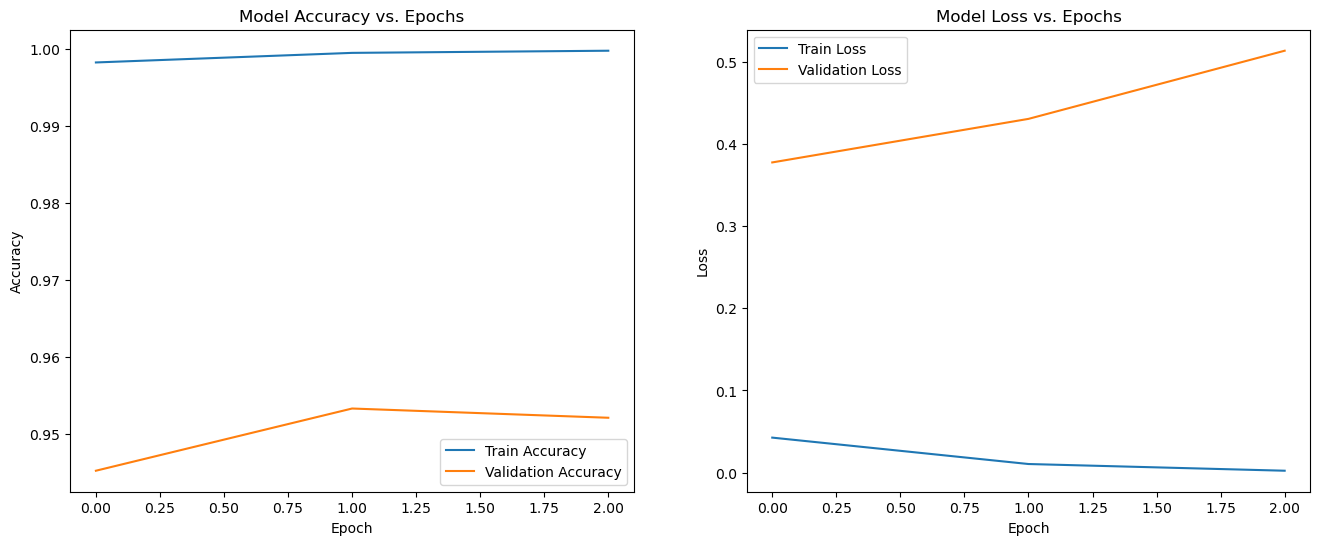

In [8]:
print("\n" + "="*60)
print("Step 6: Evaluating the final model on the test set...")
print("="*60)

# load the best model from the final training run
final_model.load_state_dict(torch.load(MODEL_SAVE_PATH))
test_loader = create_data_loader(X_test, y_test, tokenizer, MAX_LEN, best_params['batch_size'])

# epoch history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.plot(history['train_acc'], label='Train Accuracy')
ax1.plot(history['val_acc'], label='Validation Accuracy')
ax1.set_title('Model Accuracy vs. Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax2.plot(history['train_loss'], label='Train Loss')
ax2.plot(history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss vs. Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
plt.show()

Getting Final Predictions:   0%|          | 0/1664 [00:00<?, ?it/s]

Inference on 13311 test samples took 64.67 seconds.

Classification Report (Test Set):
              precision    recall  f1-score   support

       Human       0.97      0.87      0.91      9717
          AI       0.72      0.92      0.81      3594

    accuracy                           0.88     13311
   macro avg       0.84      0.89      0.86     13311
weighted avg       0.90      0.88      0.89     13311



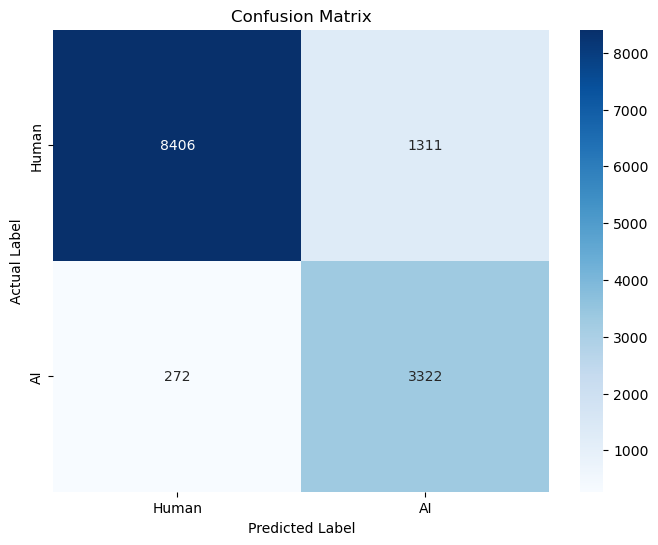

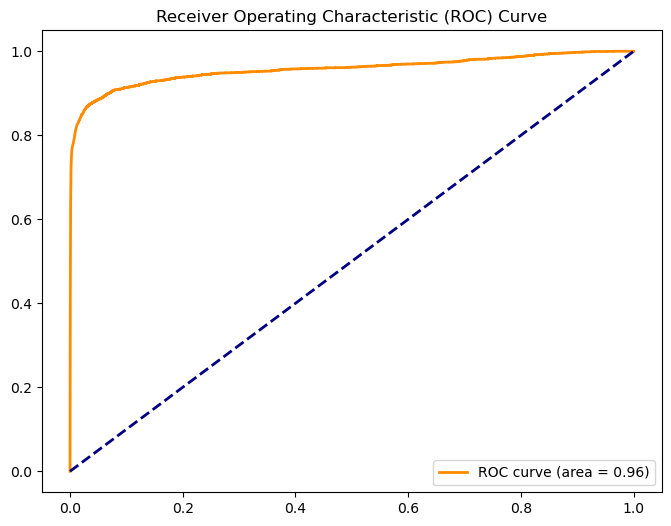

In [9]:
# final test set evaluation
y_pred_class, y_pred_prob_all, y_test_actual = [], [], []
test_inference_start_time = time.time()
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Getting Final Predictions"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        outputs = final_model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        y_pred_class.extend(preds)
        y_pred_prob_all.extend(probs)
        y_test_actual.extend(labels.cpu().numpy())
test_inference_end_time = time.time()
print(f"Inference on {len(y_test_actual)} test samples took {test_inference_end_time - test_inference_start_time:.2f} seconds.")

y_pred_prob = np.array(y_pred_prob_all)[:, 1]
print("\nClassification Report (Test Set):")
print(classification_report(y_test_actual, y_pred_class, target_names=['Human', 'AI']))

cm = confusion_matrix(y_test_actual, y_pred_class)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

fpr, tpr, _ = roc_curve(y_test_actual, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()